In [1]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, Subset, random_split, DataLoader
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
model = CNN(width=6, bn=True, normalise=False)
device = torch.device("mps")
results_dir = TRAINING_RESULTS / 'ext_high_mass' / 'good_runs' / 'run_100426_141342'
weights_path = TRAINING_RESULTS/'ext_high_mass'/'run_100426_141342'/'best_model_weights.pth'
weights_path = results_dir / 'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=12288, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

## Confusion matrix

In [3]:
DEVICE = torch.device("mps")
def accuracy(model, loader, threshold=0.5):
    model.eval()
    
    soft_correct, hard_correct, soft_total, hard_total = 0, 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            images, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > threshold).float()
            soft_correct += (predicted == labels).sum().item()
            hard_correct += ((predicted == labels).all(dim=1)).sum().item()
            soft_total += labels.numel()
            hard_total += labels.size(0)
    
    soft_acc = soft_correct/soft_total
    hard_acc = hard_correct/hard_total
    return soft_acc, hard_acc

In [4]:
dataset = LISADataset(training_ehm_dataset_path)

unique_indices = np.unique(dataset.sim_indices)
all_indices = np.array(dataset.sim_indices)

rng = np.random.default_rng(42)
rng.shuffle(unique_indices)

n_total = len(unique_indices)
n_train = int(0.7 * n_total)
n_val   = int(0.2 * n_total)

train_sources = unique_indices[:n_train]
val_sources   = unique_indices[n_train:n_train+n_val]
test_sources  = unique_indices[n_train+n_val:]

train_indices = np.where(np.isin(all_indices, train_sources))[0]
val_indices   = np.where(np.isin(all_indices, val_sources))[0]
test_indices  = np.where(np.isin(all_indices, test_sources))[0]

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

In [5]:
train_loader = DataLoader(train_dataset, batch_size=64)
train_soft_acc, train_hard_acc = accuracy(model, train_loader)

val_loader = DataLoader(val_dataset, batch_size=64)
val_soft_acc, val_hard_acc = accuracy(model, val_loader)

test_loader = DataLoader(test_dataset, batch_size=64)
test_soft_acc, test_hard_acc = accuracy(model, test_loader)

print(f"Training Soft Accuracy: {train_soft_acc:.4f}, Training Hard Accuracy: {train_hard_acc:.4f}")
print(f"Validation Soft Accuracy: {val_soft_acc:.4f}, Validation Hard Accuracy: {val_hard_acc:.4f}")
print(f"Test Soft Accuracy: {test_soft_acc:.4f}, Test Hard Accuracy: {test_hard_acc:.4f}")

Training Soft Accuracy: 0.9934, Training Hard Accuracy: 0.9869
Validation Soft Accuracy: 0.9610, Validation Hard Accuracy: 0.9223
Test Soft Accuracy: 0.9650, Test Hard Accuracy: 0.9306


In [5]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1]

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(labels)

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

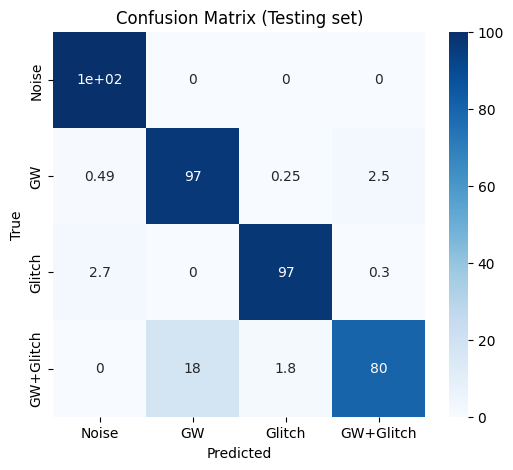

In [6]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class, normalize='true')*100
np.savez(results_dir / 'confusion_matrix.npz', cm=cm)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

In [16]:
np.where((true_class == 3)&(pred_class == 1))[0]

array([ 745,  746,  747,  748,  749,  753,  754,  755,  756,  764,  765,
        770,  771,  772,  773,  774,  790,  791,  792,  794,  798,  799,
        831,  832,  833,  834,  869,  875,  876,  877,  878,  879,  880,
        883,  884,  897,  898,  900,  901,  902,  903,  904,  915,  916,
        917,  918,  919,  920,  968,  969,  988,  989,  994, 1006, 1007,
       1008, 1009, 1034, 1045, 1053, 1055, 1056, 1058, 1059, 1065, 1066,
       1067, 1068, 1080, 1096, 1100, 1104])

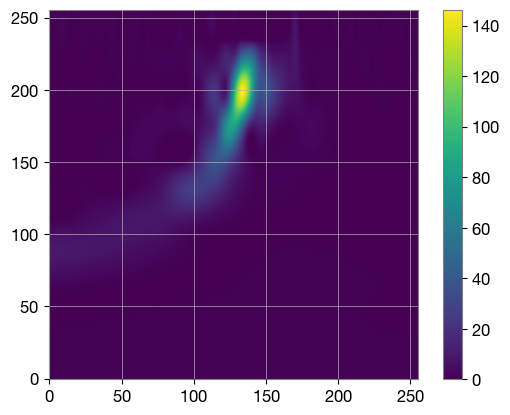

True label: tensor([1., 1.])
Sim index: 535
Time index: 3


In [37]:
image, label, sim_index, time_index = test_dataset[988]
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.show()
print('True label:', label)
print('Sim index:', sim_index)
print('Time index:', time_index)

In [15]:
wrong = np.where((true_class == 3)&(pred_class == 1))[0]
sim_indices = [test_dataset[i][2] for i in wrong]

right = np.where((true_class == 3)&(pred_class == 3))[0]
all_indices = np.array([test_dataset[i][2] for i in right])

In [16]:
sim_indices = np.unique(sim_indices)
all_indices = np.unique(all_indices)
with h5py.File(mixed_ehm_dataset_path, 'r') as f:
    amps = f['amp'][:]
    betas = f['beta'][:]
    seps= f['sep'][:]

wrong_amps = amps[sim_indices]
wrong_betas = betas[sim_indices]
wrong_seps = seps[sim_indices]

all_amps = amps[all_indices]
all_betas = betas[all_indices]
all_seps = seps[all_indices]

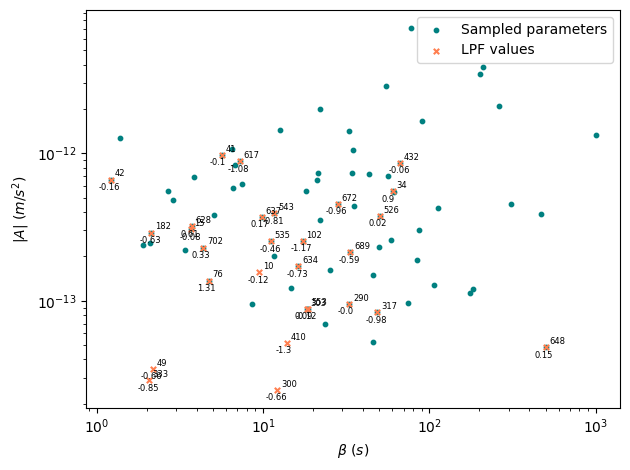

In [17]:
plt.figure(tight_layout=True)
plt.scatter(all_betas, all_amps, color='teal', s=10, label='Sampled parameters')
plt.scatter(wrong_betas, np.abs(wrong_amps), color='coral', s=15, marker='x', label='LPF values')
for i, idx in enumerate(sim_indices):
    plt.text(wrong_betas[i]*1.05, np.abs(wrong_amps[i])*1.05,
             str(idx),
             fontsize=6)
    plt.text(wrong_betas[i]*0.85, np.abs(wrong_amps[i])*0.85,
             str(round(wrong_seps[i], 2)),
             fontsize=6)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('$|A|\ (m/s^2)$')
plt.xlabel('$\\beta\ (s)$')
plt.legend()
plt.show()

In [141]:
from helpers.qtransform import generate_qscan
from helpers.simulation import make_tdi_dict

index = 102
with h5py.File(mixed_ehm_dataset_path, 'r') as f:
    X = f['X'][index]
    Y = f['Y'][index]
    Z = f['Z'][index]
    sep = f['sep'][index]
    amp = f['amp'][index]
    beta = f['beta'][index]
    m1 = f['m1'][index]
    m2 = f['m2'][index]
    spin1 = f['spin1'][index]
    spin2 = f['spin2'][index]
    d = f['d'][index]
    gw_beta = f['gw_beta'][index]
    gw_lambda = f['gw_lambda'][index]
    inj_point = f['inj_point'][index]
    t0 = f['t0'][index]

#raw_dict = {'X': X, 'Y': Y, 'Z': Z}
tdi_dict = make_tdi_dict(X, Y, Z)
event = {'t_inj': 5*3600}
tarr, farr, QT = generate_qscan(tdi_dict, 'A', PIPE, event,
                                frange=(1e-4, 1e-2), trange=(-1.5, 1.5), Q=6, resolution=256)

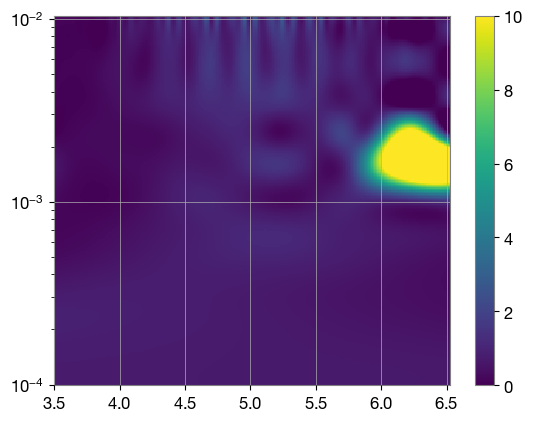

Separation: -1.172402
Beta: 17.272322


In [142]:
plt.pcolormesh(tarr/3600, farr, QT, cmap='viridis')
plt.yscale('log')
plt.clim(0, 10)
plt.colorbar()
plt.show()
print('Separation:', sep)
print('Beta:', beta)

## Re-run simulation

In [143]:
from helpers.simulation import run_simulation, run_tdi

pipe = PIPE.copy()
pipe['t0'] = float(t0)
gws = [{'type': 'BinaryInspiralGW', 'm1': m1, 'm2': m2, 'd': d,
        'spin1': spin1, 'spin2': spin2, 't_inj': pipe['t_inj'] + sep*3600, 'domain': 'freq',
        'gw_beta': gw_beta, 'gw_lambda': gw_lambda}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': pipe['t_inj'] - sep * 3600, 'beta':beta,
             'level':2*amp*beta, 'inj_point':inj_point}]

run_simulation(
            gws, glitches, pipe,
            gw_path, None, orbits_path,
            simulation_path,
            disable_noise=pipe['keep_noises'],
            seed=42
        )
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [152]:
event = gws[0]
channel = 'A'
res = 256
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

t_arr, f_arr, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=(1e-4, 1e-2), trange=(-3, 3), Q=6)

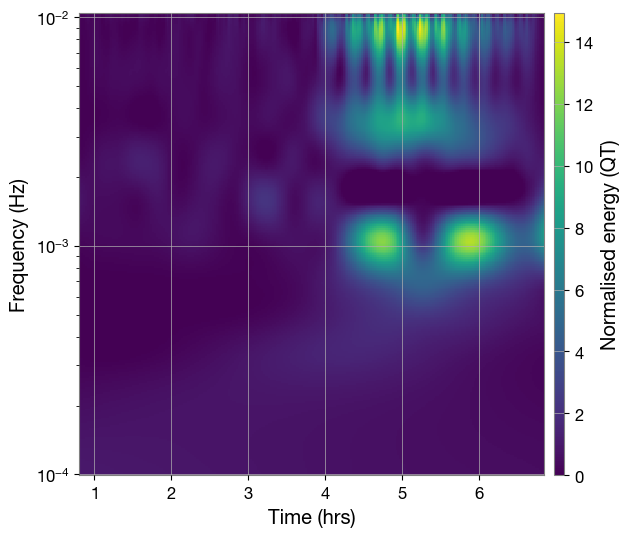

In [153]:
fig, axes = plt.subplots(1, 1, sharey=True, figsize=(6,6))

axes.pcolormesh(t_arr/3600, f_arr, QT, cmap='viridis')
axes.set_xlabel('Time (hrs)')
axes.set_ylabel('Frequency (Hz)')
axes.set_yscale('log')
axes.colorbar(label='Normalised energy (QT)')
plt.show()

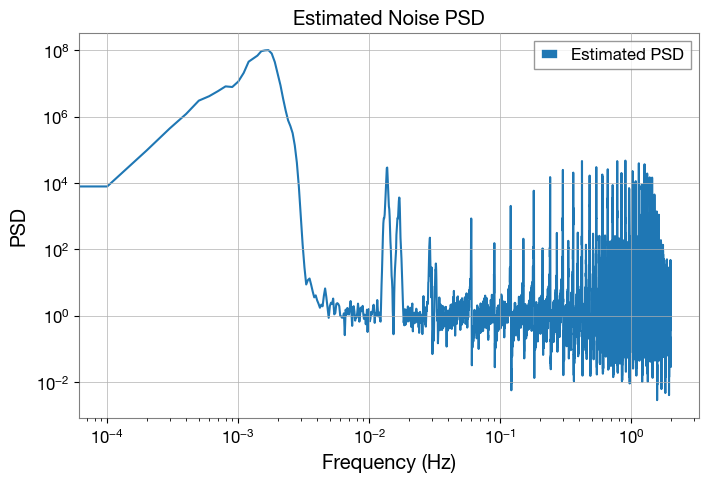

In [87]:
from dataset_generation.noise_psd_gen import estimate_psd

f_psd1, psd1 = estimate_psd(tdi_dict['A'], 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)
plt.figure(figsize=(8,5))
plt.loglog(f_psd1, psd1, label='Estimated PSD')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Estimated Noise PSD')
plt.legend()
plt.show()

## Time centering

In [18]:
from helpers.qtransform import *
from helpers.simulation import *

MASS_CATEGORY = 'ext_high_mass'  # 'low_mass', 'high_mass', 'ext_high_mass'
SPEC = SPECS[MASS_CATEGORY]

RESOLUTION = 256
REPRESENTATION = 'qscan'  # 'qscan' or 'varqscan'

def run_one_sample(args):
    tcen, X, Y, Z = args
    tdi_dict = make_tdi_dict(X, Y, Z)
    
    event = {'t_inj': PIPE['t_inj'] - tcen}

    QT = np.zeros((RESOLUTION, RESOLUTION, 3))
    for channel in ['A', 'E', 'T']:
        if REPRESENTATION == 'varqscan':
            t_arr, f_arr, data = varq_transform(tdi_dict, channel, PIPE, event, resolution=RESOLUTION,
                                        frange=SPEC['frange'], trange=SPEC['trange'], Qvals=SPEC['Qvals'])
        elif REPRESENTATION == 'qscan':
            t_arr, f_arr, data = generate_qscan(tdi_dict, channel, PIPE, event, resolution=RESOLUTION,
                             frange=SPEC['frange'], trange=SPEC['trange'], Q=SPEC['Q'])

        QT[:, :, ['A', 'E', 'T'].index(channel)] = data

    return QT, t_arr, f_arr

In [55]:
gws = [{'type': 'BinaryInspiralGW', 'm1': 2e6, 'm2': 3e6, 'd': 1e4,
        'spin1': 0, 'spin2': 0, 't_inj': PIPE['t_inj'], 'domain': 'freq',
        'gw_beta':0, 'gw_lambda':0}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': PIPE['t_inj'], 'beta':4.32e1,
             'level':2*4.91e-13*4.32e1, 'inj_point':'tm_13'}]

run_simulation(
            gws, glitches, PIPE,
            gw_path, None, orbits_path,
            simulation_path,
            disable_noise=PIPE['keep_noises'],
            seed=42
        )
raw_dict = run_tdi(simulation_path, PIPE)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [56]:
tcen_arr = np.linspace(-3, 3, 50)*3600

image_arr = np.zeros((len(tcen_arr), 256, 256, 3))
for i, tcen in enumerate(tcen_arr):
    args = (tcen, raw_dict['X'], raw_dict['Y'], raw_dict['Z'])
    QT, tarr, farr = run_one_sample(args)
    image_arr[i, :, :, :] = QT

image_arr = torch.tensor(image_arr, dtype=torch.float32)
image_arr = image_arr.permute(0, 3, 1, 2)

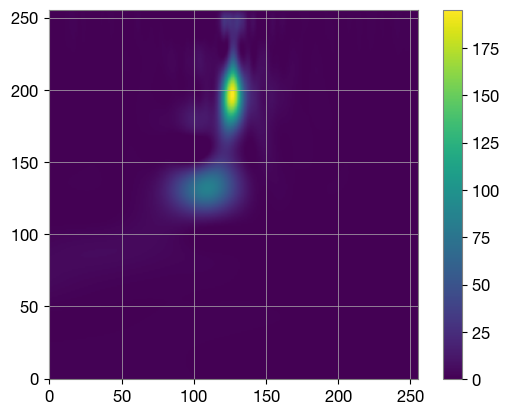

In [64]:
plt.imshow(image_arr[25][0], origin='lower')
plt.colorbar()
plt.show()

In [58]:
with torch.no_grad():
    outputs = model(image_arr.to(device).contiguous())
    probs = torch.sigmoid(outputs)

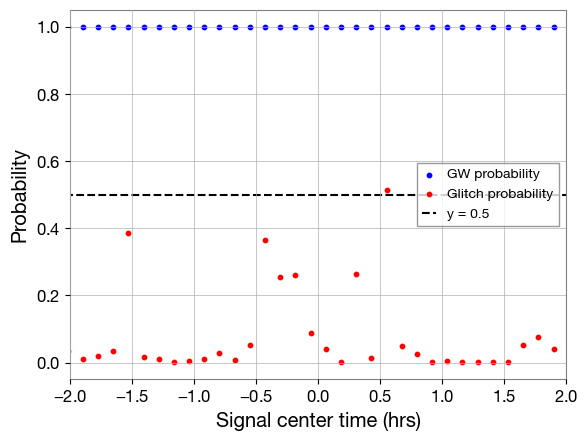

In [60]:
gw_prob = probs[:, 0].detach().cpu().numpy()
glitch_prob = probs[:, 1].detach().cpu().numpy()
tcen_act = 1.87*3600
plt.scatter(tcen_arr/3600, gw_prob, color='blue', label='GW probability', s=10)
plt.scatter(tcen_arr/3600, glitch_prob, color='red', label='Glitch probability', s=10)
plt.hlines(y=[0.5], xmin=-3, xmax=3, color='black', linestyle='dashed', label='y = 0.5')
plt.xlabel('Signal center time (hrs)')
plt.ylabel('Probability')
plt.legend(fontsize=10)
plt.xlim(-2,2)
#plt.ylim(-0.5, 1.2)
plt.show()

In [54]:
chirp_mass(2e6, 2e6)/1e6

1.741101126592247